In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
N = 100 # Gear_Ratio

folder_path = r"S:/Nit Durgapur/College 6th Sem/CSIR-CMERI/Friction_Modelling/EXP_1/EXP_1_Data/12_06_2026"
file = r"J_1_12.06.2026_13_05_36.csv"

file_path = os.path.join(folder_path, file)
df = pd.read_csv(file_path)
print(df.shape)
df.head()

(47265, 25)


,timestamp,m_t_1,m_t_2,m_t_3,m_t_4,m_t_5,m_t_6,jts1,jts2,jts3,...,v3,v4,v5,v6,q1,q2,q3,q4,q5,q6
0,13:05:36.309097,0.01830,-0.00183,-0.0,0.01062,-0.0059,0.02124,0.521055,0.337786,-0.00015,...,0.108,0.006,-0.006,-0.006,0.000687,0.000343,0.006180,0.002747,-0.000000,0.000687
1,13:05:36.314152,0.01830,-0.00183,-0.0,0.01062,-0.0059,0.02124,0.521055,0.337786,-0.00015,...,0.108,0.006,-0.006,-0.006,0.000687,0.000343,0.006180,0.002747,-0.000000,0.000687
2,13:05:36.319315,0.01830,-0.00183,-0.0,0.01062,-0.0059,0.02124,0.521055,0.337786,-0.00015,...,0.108,0.006,-0.006,-0.006,0.000687,0.000343,0.006180,0.002747,-0.000000,0.000687
3,13:05:36.324284,0.01647,-0.00549,-0.0,0.01003,-0.0059,0.02065,0.553648,0.337786,-0.00015,...,-0.054,-0.006,-0.006,-0.018,0.000687,-0.002060,0.006866,-0.000000,0.001373,-0.000687
4,13:05:36.329277,0.01647,-0.00549,-0.0,0.01003,-0.0059,0.02065,0.553648,0.337786,-0.00015,...,-0.054,-0.006,-0.006,-0.018,0.000687,-0.002060,0.006866,-0.000000,0.001373,-0.000687


In [3]:
df["q"] = np.deg2rad(df["q1"])
df["v"] = np.deg2rad(df["v1"])
df["tm"] = df["m_t_1"]
df["tj"] = df["jts1"]

In [4]:
df["tf"] = (N * df["tm"]) - df["tj"]

In [5]:
df["timestamp"] = pd.to_datetime("2026-06-12 " + df["timestamp"].astype(str))

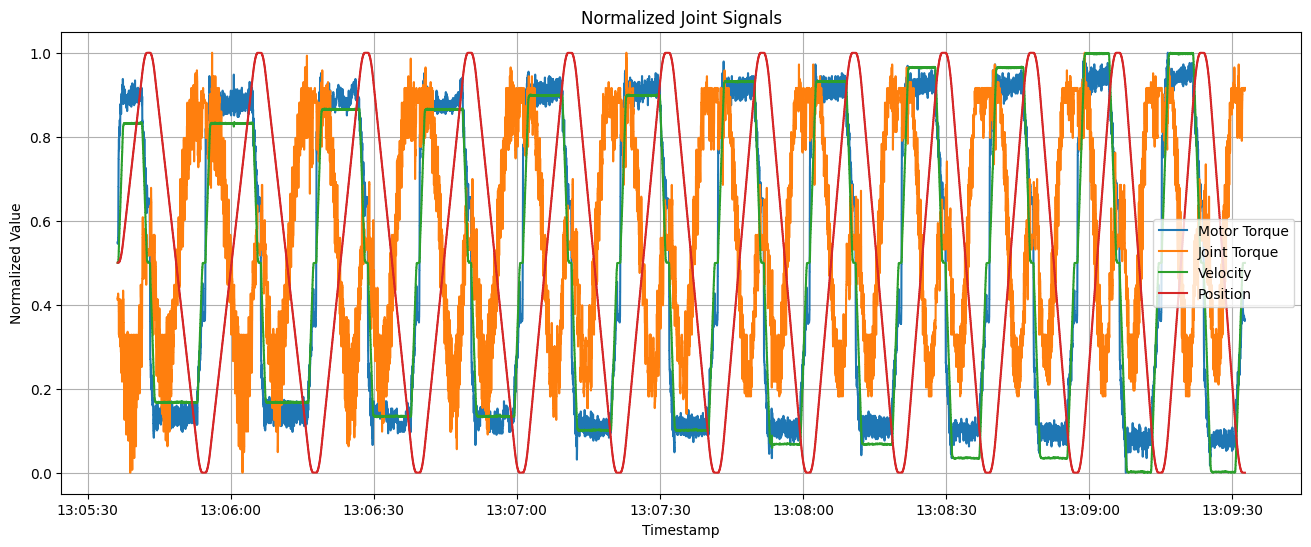

In [6]:
plot_df = df[["tm", "tj", "v", "q"]].copy()
scaler = MinMaxScaler()
plot_scaled = scaler.fit_transform(plot_df)
plot_scaled = pd.DataFrame(
    plot_scaled,
    columns=plot_df.columns
)
plt.figure(figsize=(16,6))
plt.plot(
    df["timestamp"],
    plot_scaled["tm"],
    label="Motor Torque"
)
plt.plot(
    df["timestamp"],
    plot_scaled["tj"],
    label="Joint Torque"
)
plt.plot(
    df["timestamp"],
    plot_scaled["v"],
    label="Velocity"
)
plt.plot(
    df["timestamp"],
    plot_scaled["q"],
    label="Position"
)
plt.legend()
plt.xlabel("Timestamp")
plt.ylabel("Normalized Value")
plt.title("Normalized Joint Signals")
plt.grid(True)
plt.show()

In [7]:
size = len(df)

train_end = int(0.60 * size)
val_end = int(0.80 * size)

train_df = df.iloc[: train_end]
val_df = df.iloc[train_end : val_end]
test_df = df.iloc[val_end :]

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(28359, 30)
(9453, 30)
(9453, 30)


In [8]:
def model1(v, Tc, Bv, Vs):
    return (Tc * np.tanh(v/Vs) + Bv * v)

In [9]:
v_train = train_df["v"].values
tf_train = train_df["tf"].values

p0 = [5, 0.1, 0.01]

params1, _ = curve_fit(
    model1,
    v_train,
    tf_train,
    p0 = p0,
    maxfev = 50000
)

Tc1, Bv1, Vs1 = params1

print("Tc =",Tc1)
print("Bv =",Bv1)
print("Vs =",Vs1)

Tc = 9.289417417045312
Bv = 18.728336708150163
Vs = 0.00022643477555494093


In [10]:
v_test = test_df["v"].values
tf_test = test_df["tf"].values

pred1 = model1(v_test, * params1)

In [11]:
rmse1 = np.sqrt(mean_squared_error(tf_test, pred1))
mae1 = mean_absolute_error(tf_test, pred1)
r2_1 = r2_score(tf_test, pred1)

print(rmse1)
print(mae1)
print(r2_1)

2.8042709615232684
2.1404637957491017
0.9798745348987903


In [12]:
def model2(v, Ts, Tc, Bv, Vs, alpha):
    return ((Tc + (Ts-Tc) * np.exp(-(np.abs(v)/Vs) ** alpha)) * np.tanh(v/0.001) + Bv * v)

In [13]:
p0 = [10, 5, 0.1, 0.05, 1]

params2,_ = curve_fit(
    model2,
    v_train,
    tf_train,
    p0=p0,
    maxfev=100000
)

Ts, Tc, Bv, Vs, alpha = params2

print("Tc = ", Tc)
print("Ts = ", Ts)
print("Bv = ", Bv)
print("Vs = ", Vs)
print("alpha = ", alpha)

C:\Users\HP\AppData\Local\Temp\ipykernel_22572\2944028696.py:2: RuntimeWarning: divide by zero encountered in power
  return ((Tc + (Ts-Tc) * np.exp(-(np.abs(v)/Vs) ** alpha)) * np.tanh(v/0.001) + Bv * v)
C:\Users\HP\AppData\Local\Temp\ipykernel_22572\2944028696.py:2: RuntimeWarning: invalid value encountered in power
  return ((Tc + (Ts-Tc) * np.exp(-(np.abs(v)/Vs) ** alpha)) * np.tanh(v/0.001) + Bv * v)


Tc =  10.099627333072453
Ts =  5808697.444902857
Bv =  -147.20591581120814
Vs =  544695448735.79425
alpha =  -0.08703111412073662


In [14]:
pred2 = model2(v_test, * params2)

C:\Users\HP\AppData\Local\Temp\ipykernel_22572\2944028696.py:2: RuntimeWarning: divide by zero encountered in power
  return ((Tc + (Ts-Tc) * np.exp(-(np.abs(v)/Vs) ** alpha)) * np.tanh(v/0.001) + Bv * v)


In [15]:
test_time = test_df["timestamp"]

In [16]:
rmse2 = np.sqrt(mean_squared_error(tf_test, pred2))
mae2 = mean_absolute_error(tf_test, pred2)
r2_2 = r2_score(tf_test, pred2)

print(rmse2)
print(mae2)
print(r2_2)

2.901576172971173
2.2879056318926843
0.9784536391690806


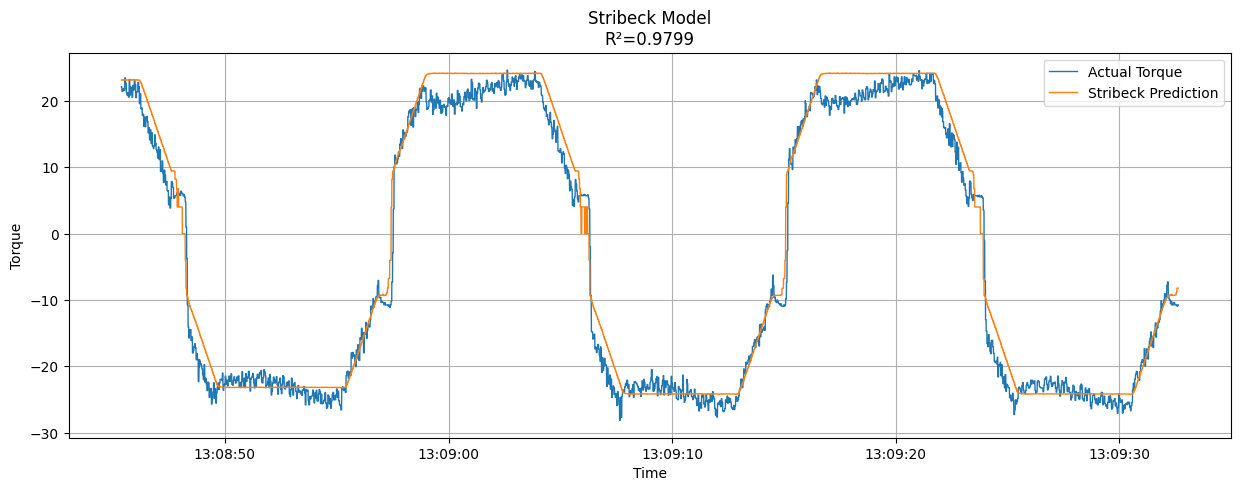

In [17]:
plt.figure(figsize=(15,5))
plt.plot(
    test_time,
    tf_test,
    label="Actual Torque",
    linewidth=1
)
plt.plot(
    test_time,
    pred1,
    label="Stribeck Prediction",
    linewidth=1
)
plt.xlabel("Time")
plt.ylabel("Torque")
plt.title(f"Stribeck Model\nR²={r2_1:.4f}")
plt.legend()
plt.grid(True)
plt.show()

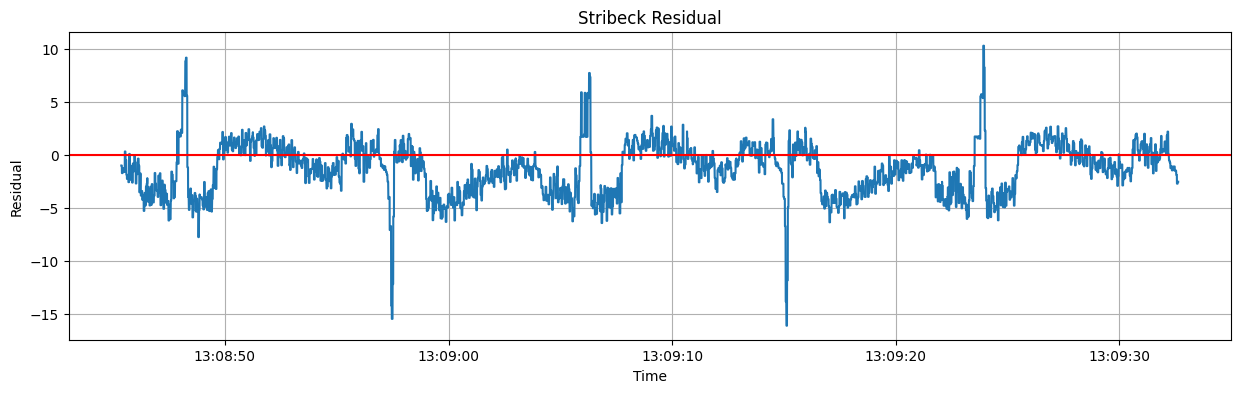

In [18]:
residual1 = tf_test - pred1
plt.figure(figsize=(15,4))
plt.plot(
    test_time,
    residual1
)
plt.axhline(
    0,
    color='red'
)
plt.xlabel("Time")
plt.ylabel("Residual")
plt.title("Stribeck Residual")
plt.grid(True)
plt.show()

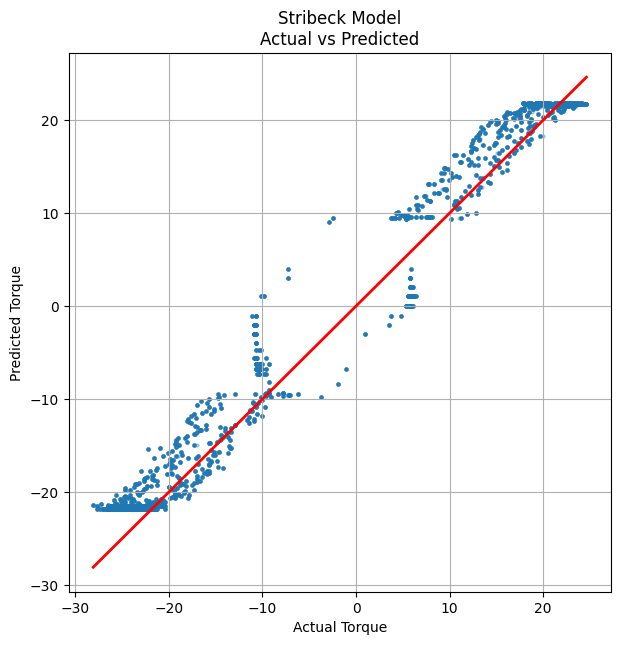

In [19]:
plt.figure(figsize=(7,7))
plt.scatter(
    tf_test,
    pred2,
    s=5,
    alpha=0.3
)
min_val = min(
    tf_test.min(),
    pred2.min()
)
max_val = max(
    tf_test.max(),
    pred2.max()
)
plt.plot(
    [min_val,max_val],
    [min_val,max_val],
    'r',
    linewidth=2
)
plt.xlabel("Actual Torque")
plt.ylabel("Predicted Torque")
plt.title("Stribeck Model\nActual vs Predicted")
plt.grid(True)
plt.show()

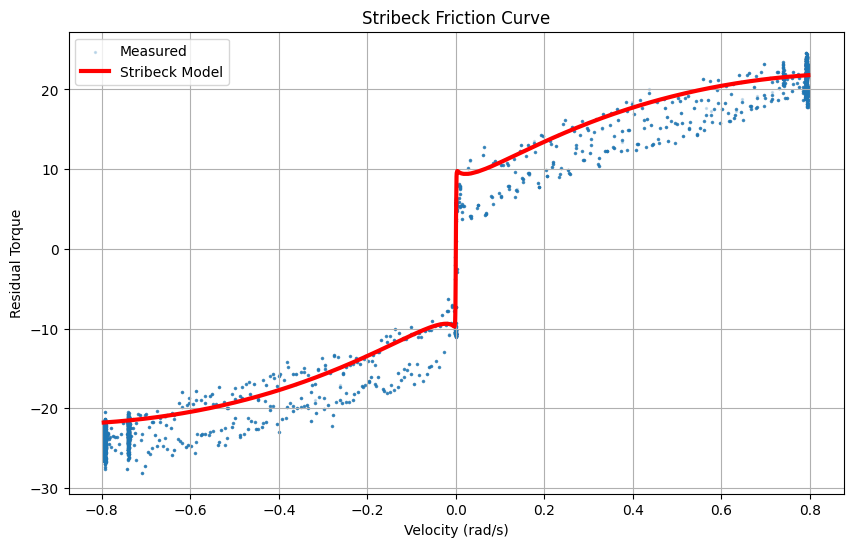

In [20]:
idx = np.argsort(v_test)
plt.figure(figsize=(10,6))
plt.scatter(
    v_test,
    tf_test,
    s=2,
    alpha=0.2,
    label="Measured"
)
plt.plot(
    v_test[idx],
    pred2[idx],
    linewidth=3,
    color='red',
    label='Stribeck Model'
)
plt.xlabel("Velocity (rad/s)")
plt.ylabel("Residual Torque")
plt.title("Stribeck Friction Curve")
plt.legend()
plt.grid(True)
plt.show()